In [1]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
from skimage.metrics import structural_similarity as ssim_id

import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
from datasets.dataset import TemperatureXZDataset
from runners.train_diffusion import forwardpass
from analysis_functions import predict_lrenc, predict_mobilenet, predict_ddim_diffusion,predict_modified_diffusion, predict_diffusion, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM

In [2]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

### Define results directory

In [3]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/diffusion/2022_12_12_02_33_57/standardize/n_steps_1'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/encoder/2022_12_04_11_32_01/standardize/'
mobilenet_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/mobilenet/2022_12_05_03_17_09'


### Plot Train, Test Loss for diffusion

In [4]:
import numpy as np
test_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'test_loss_epoch.txt'))
train_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'loss_epoch.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Test Loss')

# plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Test Loss')

# plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()
plt.yscale('log')

OSError: /home/oogoke/DiffusionSR/runs/clean/direct/diffusion/2022_12_12_02_33_57/standardize/n_steps_1/test_loss_epoch.txt not found.

In [5]:
p_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/diffusionno_residual'
sub_p_dirs = ['2022_12_19_02_51_24/standardize/n_steps_1', '2022_12_19_02_51_11/standardize/n_steps_1']
timesteps = [1000, 1500]

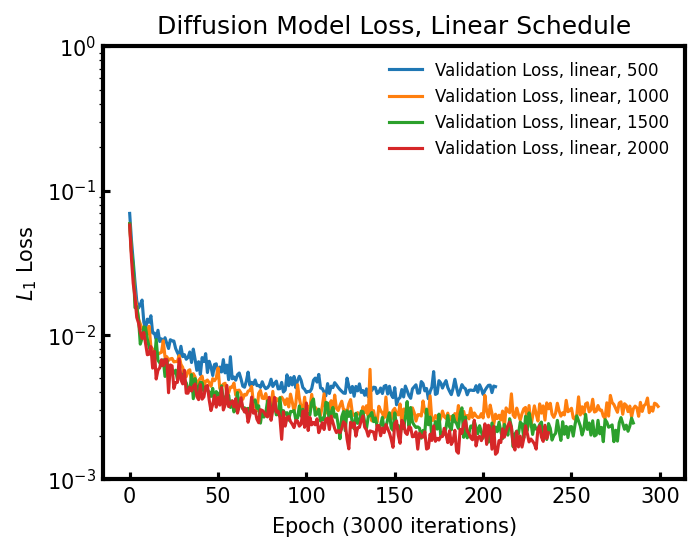

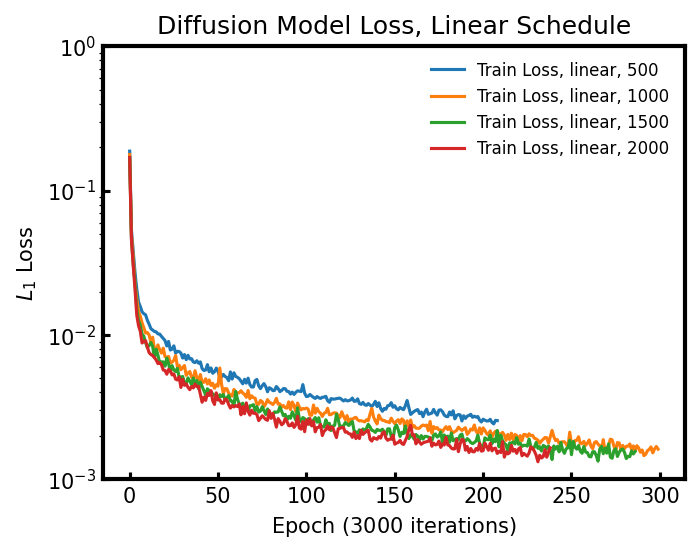

In [6]:

class Simulation():
    def __init__(self, folder, diff_steps, schedule):
        self.folder = folder
        self.diff_steps = diff_steps
        self.schedule = schedule
        self.kp = None
        self.profile = None
        self.max_depth = None
        self.kp_depth = None
    def get_loss_curve(self):
        test_loss = np.loadtxt(os.path.join(self.folder, 'test_loss_epoch.txt'))
        train_loss = np.loadtxt(os.path.join(self.folder, 'loss_epoch.txt'))
        return train_loss, test_loss
simlinear1000 = Simulation(os.path.join(p_dir, '2022_12_19_02_51_24/standardize/n_steps_1'), 1000, 'linear')
simlinear1500 =  Simulation(os.path.join(p_dir, '2022_12_19_02_51_11/standardize/n_steps_1'), 1500, 'linear')
simlinear2000 =  Simulation(os.path.join(p_dir, '2022_12_19_02_50_29/standardize/n_steps_1'), 2000, 'linear')
quadratic2000 = Simulation(os.path.join(p_dir, '2022_12_18_16_13_52/standardize/n_steps_1'), 2000, 'quadratic')
simlinear500 = Simulation(os.path.join(p_dir, '2022_12_18_16_12_08/standardize/n_steps_1'), 500, 'linear')
plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

for sim in [simlinear500, simlinear1000, simlinear1500, simlinear2000]:
    train_loss, test_loss = sim.get_loss_curve()
    

    plt.plot(test_loss[:], label = 'Validation Loss, {}, {}'.format(sim.schedule, sim.diff_steps))

    # plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

    plt.xlabel(r'Epoch ($3000$ iterations)')
    plt.ylabel(r'$L_1$ Loss')
    legend()

    plt.title('Diffusion Model Loss, Linear Schedule')
    plt.grid(which = 'major')
    frame_tick()
    plt.yscale('log')
    plt.ylim(10**(-3), 1)
plt.show()
plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

for sim in [simlinear500, simlinear1000, simlinear1500, simlinear2000]:
    train_loss, test_loss = sim.get_loss_curve()

    plt.plot(train_loss[:], label = 'Train Loss, {}, {}'.format(sim.schedule, sim.diff_steps))

    # plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

    plt.xlabel(r'Epoch ($3000$ iterations)')
    plt.ylabel(r'$L_1$ Loss')
    legend()

    plt.title('Diffusion Model Loss, Linear Schedule')
    plt.grid(which = 'major')
    frame_tick()
    plt.yscale('log')
    plt.ylim(10**(-3), 1)
plt.show()

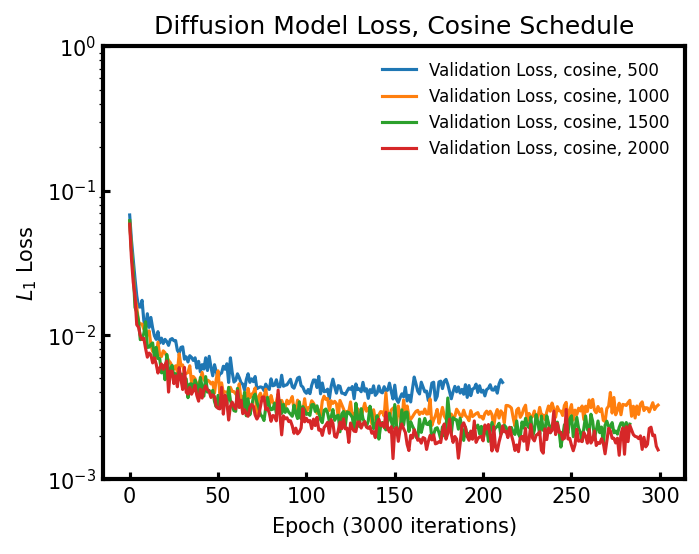

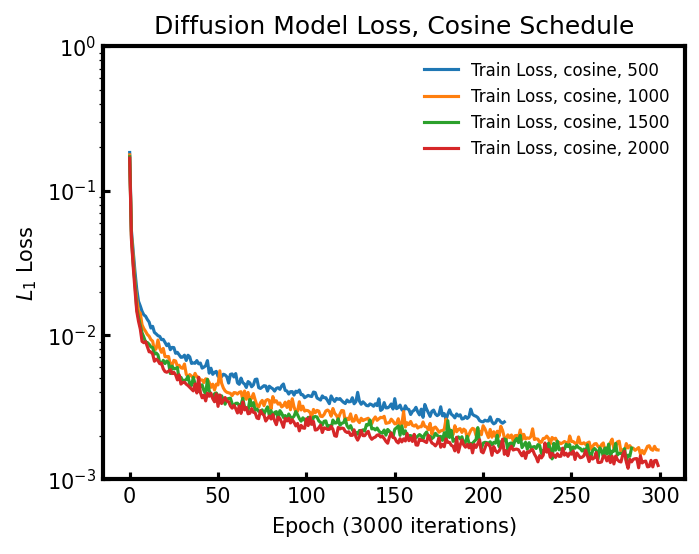

In [7]:

simcosine2000 = Simulation(os.path.join(p_dir, '2022_12_15_17_30_37/standardize/n_steps_1'), 2000, 'cosine')
simcosine1500 =  Simulation(os.path.join(p_dir, '2022_12_19_02_52_54/standardize/n_steps_1'), 1500, 'cosine')
simcosine1000 =  Simulation(os.path.join(p_dir, '2022_12_19_02_52_16/standardize/n_steps_1'), 1000, 'cosine')
quadratic2000 = Simulation(os.path.join(p_dir, '2022_12_18_16_13_52/standardize/n_steps_1'), 2000, 'quadratic')
simcosine500 = Simulation(os.path.join(p_dir, '2022_12_18_16_10_09/standardize/n_steps_1'), 500, 'cosine')

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

for sim in [simcosine500, simcosine1000, simcosine1500, simcosine2000]:
    train_loss, test_loss = sim.get_loss_curve()

    plt.plot(test_loss[:], label = 'Validation Loss, {}, {}'.format(sim.schedule, sim.diff_steps))

    # plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

    plt.xlabel(r'Epoch ($3000$ iterations)')
    plt.ylabel(r'$L_1$ Loss')
    legend()

    plt.title('Diffusion Model Loss, Cosine Schedule')
    plt.grid(which = 'major')
    frame_tick()
    plt.yscale('log')
    plt.ylim(10**(-3), 1)
plt.show()
plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)


for sim in [simcosine500, simcosine1000, simcosine1500, simcosine2000]:
    train_loss, test_loss = sim.get_loss_curve()

    plt.plot(train_loss[:], label = 'Train Loss, {}, {}'.format(sim.schedule, sim.diff_steps))

    # plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

    plt.xlabel(r'Epoch ($3000$ iterations)')
    plt.ylabel(r'$L_1$ Loss')
    legend()

    plt.title('Diffusion Model Loss, Cosine Schedule')
    plt.grid(which = 'major')
    frame_tick()
    plt.yscale('log')
    plt.ylim(10**(-3), 1)
plt.show()

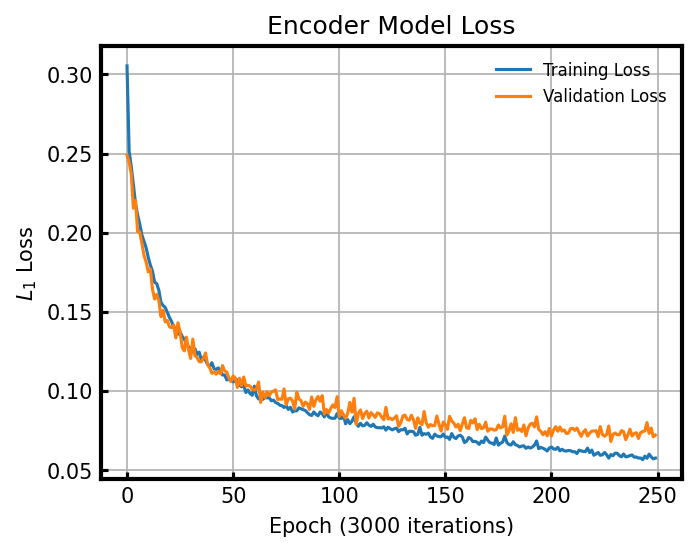

In [8]:
import numpy as np
test_loss = np.loadtxt(os.path.join(encoder_results_dir, 'test_loss.txt'))
train_loss = np.loadtxt(os.path.join(encoder_results_dir, 'train_loss.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss, label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Encoder Model Loss')
plt.grid(which = 'major')
frame_tick()

In [9]:
from datasets.dataset import SimulationXZDataset
image_size = 80
channels = 1
batch_size =16
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = '/home/oogoke/DiffusionSR/datasets/simulation_basis_laser_velocity_xz_cross_section_data', return_info = True)
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = '/home/oogoke/DiffusionSR/datasets/simulation_basis_laser_velocity_xz_cross_section_data', return_info = True)
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = '/home/oogoke/DiffusionSR/datasets/simulation_basis_laser_velocity_xz_cross_section_data', return_info = True)

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)

In [10]:
from models.diffusion_model import Unet
from models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4
os.environ['CUDA_VISIBLE_DEVICES']  = "4"
device = 'cuda'
criterion = torch.nn.L1Loss()
lr_enc = load_encoder(encoder_results_dir)
model = load_diffusion(simlinear1000.folder)
batch_size = 2
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)



In [11]:


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a

def predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape)< 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float())
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float())
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    # with torch.no_grad():
    #     n = img.size(0)
    #     seq_next = [-1] + list(seq[:-1])
    #     x0_preds = []
        
    #     x = torch.randn(shape, device=device)
    #     xs = [x]
    #     for i, j in zip(reversed(seq), reversed(seq_next)):
    #         t = (torch.ones(n) * i).to(x.device)
    #         next_t = (torch.ones(n) * j).to(x.device)
    #         at = compute_alpha(b, t.long())
    #         at_next = compute_alpha(b, next_t.long())
    #         xt = xs[-1].to('cuda')
    #         et = model(x, t, x_e)#model(xt, t)
    #         x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
    #         x0_preds.append(x0_t.to('cpu'))
    #         c1 = (
    #             kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
    #         )
    #         c2 = ((1 - at_next) - c1 ** 2).sqrt()
    #         xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
    #         xs.append(xt_next.to('cpu'))
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a

def predict_ddpm_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape)< 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float())
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float())
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        xs = [x]
        x0_preds = []
        betas = b
        for i, j in zip(reversed(seq), reversed(seq_next)):

            noise = torch.randn_like(x)

            # t = (torch.ones(n) * i).to(x.device)
            # next_t = (torch.ones(n) * j).to(x.device)
            # at = compute_alpha(betas, t.long())
            # at_next = compute_alpha(betas, next_t.long())
            # atm1 = at_next
            # xt = xs[-1].to('cuda')
            # et = model(x, t, x_e)#model(xt, t)
            # x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            # x0_preds.append(x0_t.to('cpu'))
            # c1 = (
            #     kwargs.get("eta", 1) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            # )
            # # print(c1, 'c1')
            # c2 = ((1 - at_next) - c1 ** 2).sqrt()
            # xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et + c1*noise
            # xs.append(xt_next.to('cpu'))



            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(betas, t.long())
            atm1 = compute_alpha(betas, next_t.long())
            beta_t = 1 - at / atm1
            x = xs[-1].to('cuda')

            et =model(x, t, x_e)
            # e = output

            x0_from_e = (1.0 / at).sqrt() * x - (1.0 / at - 1).sqrt() * et
            # x0_from_e = torch.clamp(x0_from_e, -1, 1)
            x0_preds.append(x0_from_e.to('cpu'))
            mean_eps = (
                (atm1.sqrt() * beta_t) * x0_from_e + ((1 - beta_t).sqrt() * (1 - atm1)) * x
            ) / (1.0 - at)

            mean = mean_eps
            # noise = torch.randn_like(x)
            mask = 1 - (t == 0).float()
            mask = mask.view(-1, 1, 1, 1)
            logvar = beta_t.log()
            sample = mean + mask * torch.exp(0.5 * logvar) * noise
            # sample = mean + mask * c1 * noise

            # print(torch.sum(sample-xt_next))
            xs.append(sample.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b



### Plot test set melt pools

torch.Size([1, 1, 80, 80])
tensor([1.0600e+02, 7.0000e+02, 5.0000e-03])
RRDNsaved_figures/power106.0vel700.0/batch_000000_time0005000 0


IndexError: Replacement index 1 out of range for positional args tuple

<Figure size 540x405 with 0 Axes>

<Figure size 540x405 with 0 Axes>

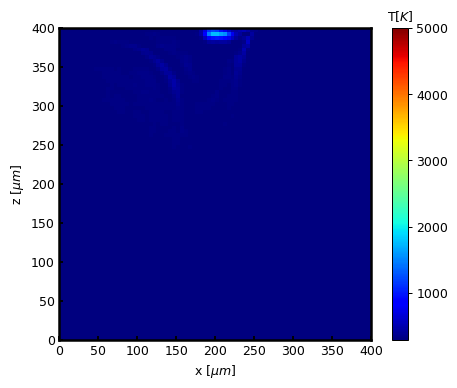

In [12]:
# model = load_diffusion(simlinear2000.folder)
# mobilenet = load_mobilenet(mobilenet_results_dir)
last_power = ''
modeltype = 'RRDN'
import time 
for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(dev_dataloader):  
    for timesteps in [200]:
    # timesteps = 2000
        for skips in [1]:
            oldtime = time.time()
            print(res.shape)

            input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
            input, result_diffusion, target, xs, b = predict_ddpm_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,train_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'linear')
            info = info[0]
            time_elapsed = time.time()-oldtime
            print(info)
            # print('power' + str(info[0].item()))# + 'vel' + str(info[1].item()))
            if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
                 timestep = 0
            else:
                timestep += 1
            folder = modeltype + 'saved_figures/'  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item()) 

            os.makedirs(folder,exist_ok = True)
            title  = os.path.join(folder, 'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))))
            print(title, timestep)
            # print(input.shape, result_diffusion.shape, target.shape)
            plot_images(input[0], result[0], target[0][0], timestep = timestep, split = 'Validation', modeltype =modeltype, timesteps = timesteps//skips, title =  title)
            print(time_elapsed, "elapsed time")
            last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
    # break


In [ ]:
# .max()
plt.imshow(train_dataset.unscale_data(hr, input_type='hr')[0][0].T, origin = 'lower')

In [ ]:
hr.shape

In [ ]:

def SSIM(op, t, batch_size):
    ssim = 0 
    # print(op.shape, t.shape)
    
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[i][0].detach().cpu().numpy(), t[i][0].detach().cpu().numpy())#, full=True)
        else:
            score = ssim_id(op[i][0], t[i][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim



# max_depth_diff = []
max_depth_gt = []
max_depth_input = []
# kp_depth_enc = []
# kp_depth_diff = []
# kp_depth_mbn = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
psnrs_lr = []
psnrs_diff= []

ssims_diff = []
ssims_lr = []

l1_lr = []
l1_diff = []

sample_times = []
steps_list= []
psnr_mean_lr = []
ssim_mean_lr = []
l1_mean_lr = []
ssim_mean_diff = []
psnr_mean_diff = []
l1_mean_diff = []
l1loss = nn.L1Loss()
# sample_diff_steps = [50, 100,200, 500, 1000, 1500, 2000]
sim = simlinear1500
timesteps=1500
model = load_diffusion(sim.folder)
for skips in [1, 2, 3, 5, 10, 15, 20, 50]:
    diff_steps = sim.diff_steps
# for diff_steps in sample_diff_steps:
    kp_depth_diff = []
    max_depth_diff = []
    max_depth_input= []
    kp_depth_input = []
    max_depth_gt  = []
    kp_depth_gt = []
    psnr_batches_lr = []
    psnr_batches_diff = []
    l1_batches_diff = []
    l1_batches_lr = []
    ssim_batches_lr = []
    ssim_batches_diff = []
    print(skips)
    for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
        oldtime = time.time()
        input, result_diffusion, target, _, _ = predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,train_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'linear')
        # print(result_diffusion.shape)
        upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
        lrpsnr = PSNR(upscale, target, target.shape[0]).item()

        diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()
        # print(lrpsnr, diffpsnr)
        psnr_batches_diff.append(diffpsnr)
        psnr_batches_lr.append((lrpsnr))
        lrssim = SSIM(upscale, target.view(upscale.shape), target.shape[0])
        diffssim = SSIM(result_diffusion, target.view(upscale.shape), target.shape[0])
        lrl1 = l1loss(upscale, target)
        # print('shape printing here')
        # print(type(result_diffusion), type(target))
        # print(result_diffusion.shape, target.shape)
        diffl1 = l1loss(torch.tensor(result_diffusion), target)
        # print('LR SSIM: ',  SSIM(upscale, target.view(upscale.shape), target.shape[0]))
        # print(result_diffusion.shape, target.shape, 'shapes result diffusion target')
        # print('Diffusion SSIM: ',  SSIM(result_diffusion, target.view(upscale.shape), target.shape[0]))
        ssim_batches_lr.append(lrssim)
        ssim_batches_diff.append(diffssim)
        l1_batches_lr.append(lrl1)
        l1_batches_diff.append(diffl1)
        for i, rd in enumerate(result_diffusion):
            elapsed = time.time() - oldtime
            if batch_idx == 0:
                sample_times.append(elapsed)
                steps_list.append(timesteps//skips)
            profile_diff, kp_diff = get_profile(result_diffusion[i])
            # print(target.shape)
            profile_gt, kp_gt = get_profile(target[i])
            profile_input, kp_input = get_profile(input[i], mesh = 20)
            # plt.imshow(target[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.imshow(result_diffusion[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.plot(profile_diff)
            # plt.plot(profile_gt)
            # # plt.plot(profile_input)
            # plt.show()


            max_depth_gt.append(5*(80-np.min(profile_gt)))
            max_depth_diff.append(5*(80-np.min(profile_diff)))
            max_depth_input.append(20*(20-np.min(profile_input)))
            kp_depth_gt.append(5*(80-np.min(kp_gt)))
            kp_depth_input.append(20*(20-np.min(kp_input)))
            kp_depth_diff.append(5*(80-np.min(kp_diff)))



        # plt.plot(profile_diff)
        # plt.show()
        # if batch_idx > 9:
        #     break
    kp_depth_diffs.append(kp_depth_diff)
    max_depth_diffs.append(max_depth_diff)
    ssims_diff.append(ssim_batches_diff)
    ssims_lr.append(ssim_batches_lr)
    l1_lr.append(l1_batches_lr)
    psnrs_lr.append(psnr_batches_lr)
    psnrs_diff.append(psnr_batches_diff)
    l1_diff.append(l1_batches_diff)
    psnr_mean_lr.append(np.mean(psnr_batches_lr))
    psnr_mean_diff.append(np.mean(psnr_batches_diff))
    ssim_mean_diff.append(np.mean(ssim_batches_diff))
    ssim_mean_lr.append(np.mean(ssim_batches_lr))
    l1_mean_lr.append(np.mean(l1_batches_lr))
    l1_mean_diff.append(np.mean(l1_batches_diff))
    
    print(ssim_mean_lr)


In [ ]:
input[0]

In [ ]:
# timesteps = 1500
for 
for timesteps in [200]:
    for skips in [1]:#, 2, 3, 5, 10, 15, 20, 50]:
        oldtime = time.time()
        input, result_diffusion, target, xs, b = predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,train_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'linear')
        time_elapsed = time.time()-oldtime
        print(input.shape, result_diffusion.shape, target.shape)
        plot_images(input[0], result_diffusion[0], target[0][0], split = 'Validation', modeltype = "Diffusion", timesteps = timesteps//skips)
        print(time_elapsed, "elapsed time")

In [ ]:
# plt.imshow(xs[-1][0][0].detach().cpu().numpy())
plt.plot(b)

In [ ]:
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmin = -100, vmax= 0)
plt.colorbar()
plt.show()
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmax= 293)
plt.colorbar()
plt.show()
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmin = 293, vmax= 1900)
plt.colorbar()
plt.show()
plt.imshow(result_diffusion[0].T, cmap ='jet', origin = 'lower', vmin= 293, vmax = 5000)
plt.colorbar()
plt.show()
plt.imshow(dev_dataloader.dataset.unscale_data(res[0,0].T.cpu().numpy(), input_type = 'residual'), cmap = 'jet', origin = 'lower')
plt.colorbar()

### Calculate melt pool and keyhole dimensions

In [ ]:
def get_inst_profile(image, mesh = 5):
    image = image[0].T
    print(image.shape)
    binarized = image > 1900
    profile = []
    keyholeprofile = []
    for i in range(binarized.shape[1]):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:
            profile.append(np.min(coords))
            keyholeprofile.append(np.max(coords))
        else:
            profile.append(binarized.shape[1])
            keyholeprofile.append(binarized.shape[1])
    profile = np.array(profile)
    keyholeprofile = np.array(keyholeprofile)
    return(profile, keyholeprofile)

In [ ]:
# max_depth_diff = []
max_depth_gt = []
max_depth_input = []
# kp_depth_enc = []
# kp_depth_diff = []
# kp_depth_mbn = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
sample_times = []
steps_list= []
for skips in [50]:
    kp_depth_diff = []
    max_depth_diff = []
    max_depth_input= []
    kp_depth_input = []
    max_depth_gt  = []
    kp_depth_gt = []
    for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
        oldtime = time.time()
        input, result_diffusion, target, _, _ = predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'linear')
        # print(result_diffusion.shape)
        for i, rd in enumerate(result_diffusion):
            elapsed = time.time() - oldtime
            if batch_idx == 0:
                sample_times.append(elapsed)
                steps_list.append(timesteps//skips)
            profile_diff, kp_diff = get_profile(result_diffusion[i])
            # print(target.shape)
            profile_gt, kp_gt = get_profile(target[i])
            profile_input, kp_input = get_profile(input[i], mesh = 20)
            max_depth_gt.append(5*(80-np.min(profile_gt)))
            max_depth_diff.append(5*(80-np.min(profile_diff)))
            max_depth_input.append(20*(20-np.min(profile_input)))
            kp_depth_gt.append(5*(80-np.min(kp_gt)))
            kp_depth_input.append(20*(20-np.min(kp_input)))
            kp_depth_diff.append(5*(80-np.min(kp_diff)))
        # plt.plot(profile_diff)
        # plt.show()
        if batch_idx > 2:
            break
    kp_depth_diffs.append(kp_depth_diff)
    max_depth_diffs.append(max_depth_diff)



In [ ]:

def SSIM(op, t, batch_size):
    ssim = 0 
    # print(op.shape, t.shape)
    
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[i][0].detach().cpu().numpy(), t[i][0].detach().cpu().numpy())#, full=True)
        else:
            score = ssim_id(op[i][0], t[i][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim



# max_depth_diff = []
max_depth_gt = []
max_depth_input = []
# kp_depth_enc = []
# kp_depth_diff = []
# kp_depth_mbn = []
kp_depth_gt = []
kp_depth_input = []
kp_depth_diffs = []
max_depth_diffs = []
psnrs_lr = []
psnrs_diff= []

ssims_diff = []
ssims_lr = []

l1_lr = []
l1_diff = []

sample_times = []
steps_list= []
psnr_mean_lr = []
ssim_mean_lr = []
l1_mean_lr = []
ssim_mean_diff = []
psnr_mean_diff = []
l1_mean_diff = []
l1loss = nn.L1Loss()
sample_diff_steps = [50, 100,200, 500, 1000, 1500, 2000]
sim = simlinear2000
# for sim in [simlinear500, simlinear1000, simlinear1500, simlinear2000]:
for diff_steps in sample_diff_steps:
    kp_depth_diff = []
    max_depth_diff = []
    max_depth_input= []
    kp_depth_input = []
    max_depth_gt  = []
    kp_depth_gt = []
    psnr_batches_lr = []
    psnr_batches_diff = []
    l1_batches_diff = []
    l1_batches_lr = []
    ssim_batches_lr = []
    ssim_batches_diff = []

    for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
        oldtime = time.time()
        input, result_diffusion, target = predict_modified_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dev_dataset, timesteps =diff_steps)
        # print(result_diffusion.shape)
        upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
        lrpsnr = PSNR(upscale, target, target.shape[0]).item()

        diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()
        # print(lrpsnr, diffpsnr)
        psnr_batches_diff.append(diffpsnr)
        psnr_batches_lr.append((lrpsnr))
        lrssim = SSIM(upscale, target.view(upscale.shape), target.shape[0])
        diffssim = SSIM(result_diffusion, target.view(upscale.shape), target.shape[0])
        lrl1 = l1loss(upscale, target)
        # print('shape printing here')
        # print(type(result_diffusion), type(target))
        # print(result_diffusion.shape, target.shape)
        diffl1 = l1loss(torch.tensor(result_diffusion), target)
        # print('LR SSIM: ',  SSIM(upscale, target.view(upscale.shape), target.shape[0]))
        # print(result_diffusion.shape, target.shape, 'shapes result diffusion target')
        # print('Diffusion SSIM: ',  SSIM(result_diffusion, target.view(upscale.shape), target.shape[0]))
        ssim_batches_lr.append(lrssim)
        ssim_batches_diff.append(diffssim)
        l1_batches_lr.append(lrl1)
        l1_batches_diff.append(diffl1)
        for i, rd in enumerate(result_diffusion):
            elapsed = time.time() - oldtime
            if batch_idx == 0:
                sample_times.append(elapsed)
                steps_list.append(diff_steps)
            profile_diff, kp_diff = get_profile(result_diffusion[i])
            # print(target.shape)
            profile_gt, kp_gt = get_profile(target[i])
            profile_input, kp_input = get_profile(input[i], mesh = 20)
            # plt.imshow(target[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.imshow(result_diffusion[i].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
            # plt.show()
            # plt.plot(profile_diff)
            # plt.plot(profile_gt)
            # # plt.plot(profile_input)
            # plt.show()


            max_depth_gt.append(5*(80-np.min(profile_gt)))
            max_depth_diff.append(5*(80-np.min(profile_diff)))
            max_depth_input.append(20*(20-np.min(profile_input)))
            kp_depth_gt.append(5*(80-np.min(kp_gt)))
            kp_depth_input.append(20*(20-np.min(kp_input)))
            kp_depth_diff.append(5*(80-np.min(kp_diff)))



        # plt.plot(profile_diff)
        # plt.show()
        # if batch_idx > 9:
        #     break
    kp_depth_diffs.append(kp_depth_diff)
    max_depth_diffs.append(max_depth_diff)
    ssims_diff.append(ssim_batches_diff)
    ssims_lr.append(ssim_batches_lr)
    l1_lr.append(l1_batches_lr)
    psnrs_lr.append(psnr_batches_lr)
    psnrs_diff.append(psnr_batches_diff)
    l1_diff.append(l1_batches_diff)
    psnr_mean_lr.append(np.mean(psnr_batches_lr))
    psnr_mean_diff.append(np.mean(psnr_batches_diff))
    ssim_mean_diff.append(np.mean(ssim_batches_diff))
    ssim_mean_lr.append(np.mean(ssim_batches_lr))
    l1_mean_lr.append(np.mean(l1_batches_lr))
    l1_mean_diff.append(np.mean(l1_batches_diff))
    
    print(ssim_mean_lr)



In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
maes_depth = []
for max_depth, skips in zip(max_depth_diffs, [1, 2, 3, 5, 10, 15, 20, 50]):
    plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(timesteps//skips))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
    mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
    maes_depth.append(mae_depth_diff)
    print(mae_depth_diff, max_depth)
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
maes_depth = []
for kp_depth, skips in zip(kp_depth_diffs, [1, 2, 3, 5, 10, 15, 20, 50]):
    plt.scatter(kp_depth_gt, kp_depth, s = 3.0, label = 'Super Resolution, {}'.format(timesteps//skips))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
    mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth)
    maes_depth.append(mae_depth_diff)
    # print(mae_depth_diff, max_depth)
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
    print(maes_depth)
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

In [ ]:
import json
plt.figure(dpi =150)
frame_tick()
ssims_diff_loaded = json.load(open('trained_steps_dev_ssims_diff.json'))
ssims_loaded = [np.mean(load) for load in ssims_diff_loaded]
plt.plot(np.array(1500/np.array([1, 2, 3, 5, 10, 15, 20, 50])), ssim_mean_lr*np.ones_like([1, 2, 3, 5, 10, 15, 20, 50]), label = 'Low Resolution Input')

# plt.plot([1, 2, 3, 5, 10, 15, 20, 50], ssim_mean_lr*np.ones_like([1, 2, 3, 5, 10, 15, 20, 50]), label = 'Low Resolution Input')
plt.plot(np.array([500, 1000, 1500,2000]), ssims_loaded, 'rx--', label = 'DDPM Super Resolution Output')
plt.plot(np.array(1500/np.array([1, 2, 3, 5, 10, 15, 20, 50])), ssim_mean_diff, 'kx--', label = 'DDIM Super Resolution Output')
plt.ylim([0, 1])
plt.legend()
plt.xlabel('Sampling Time Reduction Factor')
# plt.xlim([0,52])
plt.ylabel(r'SSIM')
plt.grid()
plt.title("DDIM Sampling, Validation data")

In [ ]:
import json
plt.figure(dpi =150)
frame_tick()
title = '$L_1$ '
fname = 'l1'
field_diff = l1_mean_diff
field_lr = l1_mean_lr
diff_loaded = json.load(open('trained_steps_dev_{}_diff.json'.format(fname)))
loaded = [np.mean(load) for load in diff_loaded]
plt.plot(np.array(1500/np.array([1, 2, 3, 5, 10, 15, 20, 50])), field_lr*np.ones_like([1, 2, 3, 5, 10, 15, 20, 50]), label = 'Low Resolution Input')

# plt.plot([1, 2, 3, 5, 10, 15, 20, 50], ssim_mean_lr*np.ones_like([1, 2, 3, 5, 10, 15, 20, 50]), label = 'Low Resolution Input')
plt.plot(np.array([500, 1000, 1500,2000]), loaded, 'rx--', label = 'DDPM Super Resolution Output')
plt.plot(np.array(1500/np.array([1, 2, 3, 5, 10, 15, 20, 50])), field_diff, 'kx--', label = 'DDIM Super Resolution Output')
plt.ylim([0, 300])
plt.legend()
plt.xlabel('Diffusion Steps')
# plt.xlim([0,52])
plt.ylabel(r'{}'.format(title))
plt.grid()
plt.title("DDIM vs DDPM Sampling, Validation data")

In [ ]:
# print(psnr_mean_lr)
# print(psnr_mean_diff)
# print(ssim_mean_lr)
# print(ssim_mean_diff)
# print(l1_mean_lr)
plt.plot(np.array(sample_times[::16])/16,l1_mean_diff, 'kx--')
plt.xlabel('Sample Generation Time [s]')
plt.ylabel(r'$L_1$ Error [K]')
plt.ylim([0, 100])
plt.xlim([0, 6])
frame_tick()
# plt.plot(sample_times[::16],timesteps/np.array([1, 2, 3, 5, 10, 15, 20, 50]))

# sample_times[::16]
# 128/8


In [ ]:
# plt.plot(sample_diff_steps,psnr_mean_lr)
# plt.plot(sample_diff_steps, psnr_mean_diff)

# ssims_lr
# ssims_diff
import json

In [ ]:
outpath = "psnrs_diff.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(psnrs_diff))
outpath = "psnrs_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(psnrs_lr))
outpath = "ssims_diff.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(ssims_diff))
outpath = "ssims_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(ssims_lr))
outpath = "l1_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(l1_lr_numpy))
outpath = "l1_diff.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(l1_diff_numpy))

In [ ]:
l1_diff_numpy = [[l.item() for l in l1d] for l1d in l1_diff]
l1_lr_numpy = [[l.item() for l in l1d] for l1d in l1_lr]

In [ ]:
outpath = "psnr_lr.json"
with open(outpath, 'w') as f:
    f.write(json.dumps(psnrs_lr))

In [ ]:
ssims_diff_loaded = json.load(open('l1_lr.json'))
ssims_loaded = [np.mean(load) for load in ssims_diff_loaded]
plt.plot(ssims_loaded)

In [ ]:
plt.plot(ssim_mean_lr)
plt.plot(ssim_mean_diff)

In [ ]:
plt.plot(l1_mean_lr)
plt.plot(l1_mean_diff)

In [ ]:
# kp_depth_diffs# get_inst_profile(result_diffusion)
# batch_idx
sample_times

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
maes_depth = []
for max_depth, sim in zip(max_depth_diffs, [simlinear500, simlinear1000, simlinear1500, simlinear2000]):
    plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(sim.diff_steps))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
    mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
    maes_depth.append(mae_depth_diff)
    print(mae_depth_diff, max_depth)
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
kps_depth = []
maes_depth = []

for max_depth, sim in zip(max_depth_diffs, [simlinear500, simlinear1000, simlinear1500, simlinear2000]):
    plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution, {}'.format(sim.diff_steps))
    # plt.scatter(max_depth_gt, max_depth_enc, s = 3.0, label = 'Super Resolution')
    # plt.scatter(max_depth_gt, max_depth_mbn, s = 3.0, label = 'Super Resolution')

    mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
    mae_depth_diff = mean_absolute_error(max_depth_gt, max_depth)
    maes_depth.append(mae_depth_diff)
    print(mae_depth_diff, max_depth)
    kps_depth.append()
    # mae_depth_enc = mean_absolute_error(max_depth_gt, max_depth_enc)
    # mae_depth_mbn = mean_absolute_error(max_depth_gt, max_depth_mbn)
    plt.xlim(0,300)
    plt.ylim(0,300)
    frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
# plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
# plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )
plt.legend(fontsize = 5, loc = 'lower right')
plt.show()

In [ ]:
plt.plot(steps_list[::12], maes_depth, '.')
frame_tick()
plt.xlabel('Sampling Timesteps')
plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
plt.show()
frame_tick()

plt.plot(steps_list[::12], sample_times[::12], '.')
plt.xlabel('Sampling Timesteps')
plt.ylabel(r'Elapsed Time (s)')
plt.show()


plt.plot(steps_list[::12], maes_depth, '.')
frame_tick()
plt.xlabel('Sampling Timesteps')
plt.ylabel(r'$L_1$ Error: Melt Pool Depth')
plt.show()
frame_tick()


In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_mbn, s = 3.0, label = 'Super Resolution')


mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth_diff = mean_absolute_error(kp_depth_gt, kp_depth_diff)
mae_depth_enc = mean_absolute_error(kp_depth_gt, kp_depth_enc)
mae_depth_mbn = mean_absolute_error(kp_depth_gt, kp_depth_mbn)
plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Validation Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input), fontsize = 8 )
plt.text(25, 225,r'MAE SRDiff: {:.03}$\mu m$'.format(mae_depth_diff), fontsize = 8 )
plt.text(25, 200,r'MAE RRDN: {:.03}$\mu m$'.format(mae_depth_enc), fontsize = 8 )
plt.text(25, 175,r'MAE MobileNet: {:.03}$\mu m$'.format(mae_depth_mbn), fontsize = 8 )   
plt.show()

In [ ]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth_diff, s = 3.0, label = 'Super Resolution')
plt.scatter(kp_depth_gt, kp_depth_enc, s = 3.0, label = 'Super Resolution')

mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth = mean_absolute_error(kp_depth_gt, kp_depth_enc)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input) )
plt.text(25, 225,r'MAE SR: {:.03}$\mu m$'.format(mae_depth) )
plt.show()

In [ ]:
def plot_temp_lines(input, result, target, modeltype, split = 'train'):
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'direct'
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.title(r'{} model, Cross section: x = 200 $\mu m$'.format(modeltype))
    plt.plot(80*5*(np.arange(input.shape[-1])/input.shape[-1]),input[0][10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),target[40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(target.shape[-1])/target.shape[-1]),result[40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    plt.show()
plot_temp_lines(input, result_diffusion[0], target[0][0], split = 'test', modeltype = "Diffusion")
plot_temp_lines(input, lr_enc_result[0][0], target[0][0], split = 'test', modeltype = "Encoder")


In [ ]:
def plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct'):
    profile_result, kp_result = get_profile(result)

    profile_gt, kp_gt = get_profile(target)
    profile_input, kp_input = get_profile(input, mesh = 20)

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20), kp_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), kp_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80), kp_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Keyhole Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80), profile_result*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.title('[{} Data] Melt Pool Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    plt.show()
input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
print(input.shape)
input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, train_dataset)
input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, train_dataset)
plot_srdiff_contours(input, result_diffusion, target[0], split = 'Train', modeltype = "Diffusion")
plot_srdiff_contours(input, lr_enc_result, target[0], split = 'Train', modeltype = "Encoder")
plot_srdiff_contours(input, result_mobilenet, target[0], split = 'Train', modeltype = "MobileNet")


plot_images(input[0], lr_enc_result[0,0], target[0][0], split = 'Train', modeltype = "Encoder")
plot_images(input[0], result_mobilenet[0,0], target[0][0], split = 'Train', modeltype = "MobileNetSISR")
plot_images(input[0], result_diffusion[0], target[0][0], split = 'Train', modeltype = "Diffusion")


In [ ]:
profile_result, kp_result = get_profile(result_diffusion)
profile_mbn_result, kp_mbn_result = get_profile(result_mobilenet)
profile_enc_result, kp_enc_result = get_profile(lr_enc_result)
plt.step(5*np.arange(80), profile_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_enc_result - 400, label = 'Super Resolution (Output)' )
plt.step(5*np.arange(80), profile_mbn_result - 400, label = 'Super Resolution (Output)' )


In [ ]:
lrpsnrs = []

lrencpsnrs = []
diffpsnrs = []
mobilenetpsnrs = []
lrl1loss = []
lrencl1loss = []
diffl1loss = []
mobilenetl1loss= []
mobilenetssims = []
lrssims = []
diffssims = []
lrencssims = []


def SSIM(op, t, batch_size):
    ssim = 0 
    print(op.shape, t.shape)
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[0][0].detach().cpu().numpy(), t[0][0].detach().cpu().numpy())#, full=True)
        else:
            print(op[0].shape,t[0][0].detach().cpu().numpy().shape)
            score = ssim_id(op[0], t[0][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
l1loss = nn.L1Loss()
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dev_dataloader):  
    upscale = dev_dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
    input, lr_enc_result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, dev_dataset)
    print(input.shape)
    input, result_diffusion, target = predict_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,dev_dataset)
    input, result_mobilenet, target = predict_mobilenet(mobilenet,res, hr, lr, upscaled_lr, dev_dataset)
    
    lrpsnr = PSNR(upscale, target, target.shape[0]).item()
    lrencpsnr = PSNR(lr_enc_result, target, target.shape[0]).item()

    diffpsnr = PSNR(result_diffusion, target, target.shape[0]).item()

    mobilenetpsnr = PSNR(result_mobilenet, target, target.shape[0]).item()

    print('LR PSNR: ', lrpsnr)
    print('LR enc PSNR: ',PSNR(lr_enc_result, target, target.shape[0])) 
    print('Diffusion PSNR: ',PSNR(result_diffusion, target, target.shape[0])) 
    print('MobileNet PSNR: ',PSNR(result_mobilenet, target, target.shape[0])) 
    print('LR SSIM: ',  SSIM(upscale.view(upscale.shape[0],1 , upscale.shape[1], upscale.shape[2]), target, target.shape[0]))
    print('LR enc SSIM: ',  SSIM(lr_enc_result, target, target.shape[0]))
    print('Diffusion SSIM: ',  SSIM(result_diffusion, target, target.shape[0]))
    print('MobileNet SSIM: ',  SSIM(result_mobilenet, target, target.shape[0]))
    lrssim = SSIM(upscale.view(upscale.shape[0],1 , upscale.shape[1], upscale.shape[2]), target, target.shape[0])
    lrencssim = SSIM(lr_enc_result, target, target.shape[0])
    diffssim = SSIM(result_diffusion, target, target.shape[0])
    mobilenetssim = SSIM(result_mobilenet, target, target.shape[0])

    (lr_enc_result, target)
    lrpsnrs.append(lrpsnr)
    lrencpsnrs.append(lrencpsnr)
    diffpsnrs.append(diffpsnr)
    lrssims.append(lrssim)#SSIM(lr_enc_result.view(lr_enc_result.shape[0],1 , lr_enc_result.shape[1], lr_enc_result.shape[2]), target, target.shape[0]))
    lrencssims.append(lrencssim)

    diffssims.append(diffssim)
    mobilenetssims.append(mobilenetssim)


    mobilenetpsnrs.append(mobilenetpsnr)
    lrl1loss.append(l1loss(upscale, target[:,0]).item())
    lrencl1loss.append(l1loss(lr_enc_result[:,0], target[:,0]).item())
    diffl1loss.append(l1loss(torch.tensor(result_diffusion), target[:,0]).item())
    mobilenetl1loss.append(l1loss(torch.tensor(result_mobilenet[:,0]), target[:,0]).item())





In [ ]:
isinstance(lr_enc_result, torch.Tensor)

In [ ]:
print(np.mean(lrl1loss))

In [ ]:
print(np.mean(lrencl1loss))

In [ ]:
print(np.mean(diffl1loss))

In [ ]:
print(np.mean(diffssims))
print(np.mean(mobilenetssims))
print(np.mean(lrencssims))
print(np.mean(lrssims))


In [ ]:
print(np.mean(mobilenetl1loss))


In [ ]:
np.mean(lrpsnrs)


In [ ]:
np.mean(lrencpsnrs)


In [ ]:
np.mean(mobilenetpsnr)


In [ ]:
np.mean(diffpsnrs)


In [ ]:
from skimage.metrics import structural_similarity as ssim_id
def SSIM(op, t, batch_size):
    ssim = 0 
    for i in range(op.shape[0]):

        score = ssim_id(op[0], t[0])#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
print('LR SSIM: ',  SSIM(lr_data, hr, hr.shape[0]))
print('SR SSIM: ',  SSIM(generated_hr, hr, hr.shape[0]))